# Part 2C — Transfer Learning: EfficientNetB0 (Experiments A & B)
**Unit:** CIS143-6 Applications of AI  
> Run after `part2b_ann_vs_cnn.ipynb`. Loads CNN Exp A from Drive as reference.

## 0. Setup & Data

In [15]:
import os, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0-dev0+selfbuilt
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
import google.colab as _colab_mod
IN_COLAB = not getattr(_colab_mod, '_IS_LOCAL_STUB', False)

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/brain_tumour_mri')
    DATA_DIR = Path('/content/brain_tumour_data')
    if not DATA_DIR.exists():
        shutil.copytree(DRIVE_DIR / 'dataset', DATA_DIR)
        print('Dataset restored from Drive.')
else:
    import kagglehub
    DRIVE_DIR = Path('../models')
    DATA_DIR = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
    print("Dataset at:", DATA_DIR)

DRIVE_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR = DATA_DIR / 'Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
print("Model folder:", DRIVE_DIR)

Dataset at: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2
Model folder: ../models


In [17]:
records = []

for cls in CLASSES:
    for img_path in (TRAIN_DIR / cls).glob('*.jpg'):
        records.append({'filepath': str(img_path), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

train_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=15, zoom_range=0.10,
    horizontal_flip=True, width_shift_range=0.10, height_shift_range=0.10)
val_test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())

cw = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight_dict = dict(enumerate(cw))
print('Class mapping:', train_gen.class_indices)

Found 3920 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [18]:
def plot_history(history, title):
    e = range(1, len(history.history['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(e, history.history['accuracy'], label='Train', lw=2)
    ax1.plot(e, history.history['val_accuracy'], label='Val', lw=2, ls='--')
    ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(e, history.history['loss'], label='Train', lw=2)
    ax2.plot(e, history.history['val_loss'], label='Val', lw=2, ls='--')
    ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

def evaluate_model(model, gen, model_name):
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    gen.reset()
    probs = model.predict(gen, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    y_true = gen.classes
    print(f'\n{model_name} — Accuracy: {acc:.4f} | Loss: {loss:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.tight_layout(); plt.show()
    return acc, probs, y_true, y_pred

## 1. Transfer Learning

## 2. EfficientNetB0 — Experiment A: Feature Extraction (Frozen Base)

In [ ]:
base_A = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_A.trainable = False

inp = tf.keras.Input(shape=(224, 224, 3))
x = base_A(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(4, activation='softmax')(x)

eff_A = tf.keras.Model(inp, out, name='effnet_frozen')
eff_A.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

trainable = sum(tf.size(v).numpy() for v in eff_A.trainable_variables)
total = sum(tf.size(v).numpy() for v in eff_A.variables)
print(f'Trainable params: {trainable:,}  |  Total params: {total:,}')

Trainable params: 328,964  |  Total params: 4,378,555


Epoch 1/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 35s 208ms/step - accuracy: 0.7865 - loss: 0.5458 - val_accuracy: 0.8643 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 2/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.8602 - loss: 0.3601 - val_accuracy: 0.8595 - val_loss: 0.3474 - learning_rate: 0.0010
Epoch 3/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - accuracy: 0.8783 - loss: 0.3140 - val_accuracy: 0.8857 - val_loss: 0.2862 - learning_rate: 0.0010
Epoch 4/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.9020 - loss: 0.2769 - val_accuracy: 0.8952 - val_loss: 0.2601 - learning_rate: 0.0010
Epoch 5/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.9064 - loss: 0.2468 - val_accuracy: 0.8988 - val_loss: 0.2444 - learning_rate: 0.0010
Epoch 6/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 0.9097 - loss: 0.2314 - val_accuracy: 0.8976 - val_loss: 0.2569 - learning_rate: 0.0010
Epoch 7/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.9

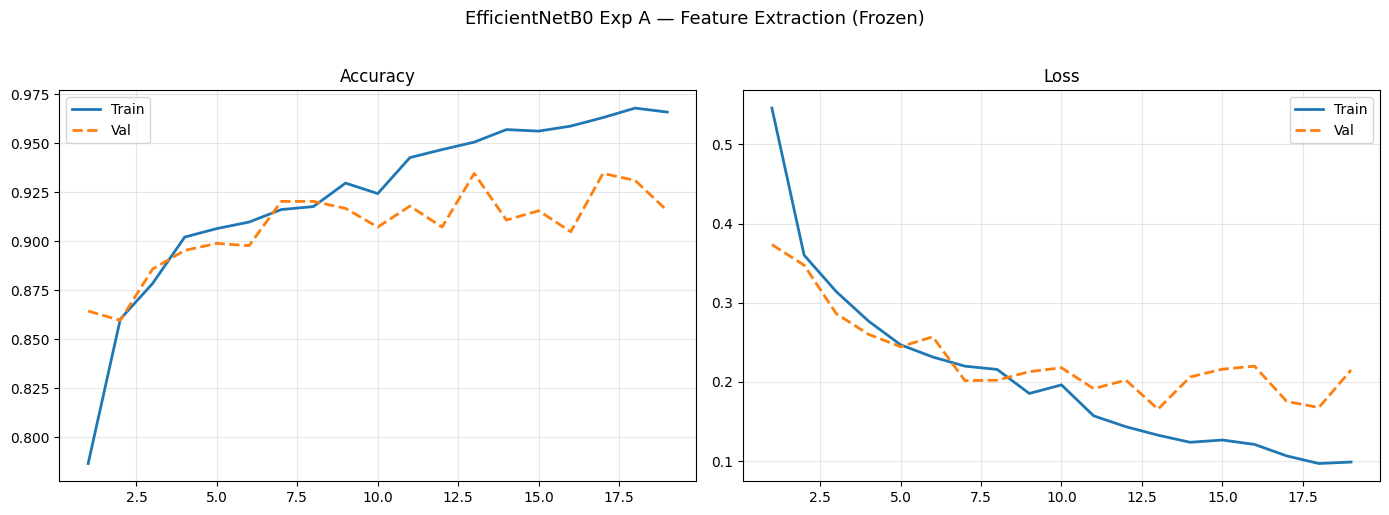

In [20]:
callbacks_effA = [
    EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(str(DRIVE_DIR / 'effnet_frozen.keras'), save_best_only=True, monitor='val_loss'),
]

hist_effA = eff_A.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks_effA,
    verbose=1,
)
plot_history(hist_effA, 'EfficientNetB0 Exp A — Feature Extraction (Frozen)')


EfficientNetB0 Exp A — Accuracy: 0.9131 | Loss: 0.2180
              precision    recall  f1-score   support

      glioma     0.9323    0.8524    0.8905       210
  meningioma     0.8411    0.8571    0.8491       210
     notumor     0.9901    0.9571    0.9734       210
   pituitary     0.8961    0.9857    0.9388       210

    accuracy                         0.9131       840
   macro avg     0.9149    0.9131    0.9129       840
weighted avg     0.9149    0.9131    0.9129       840



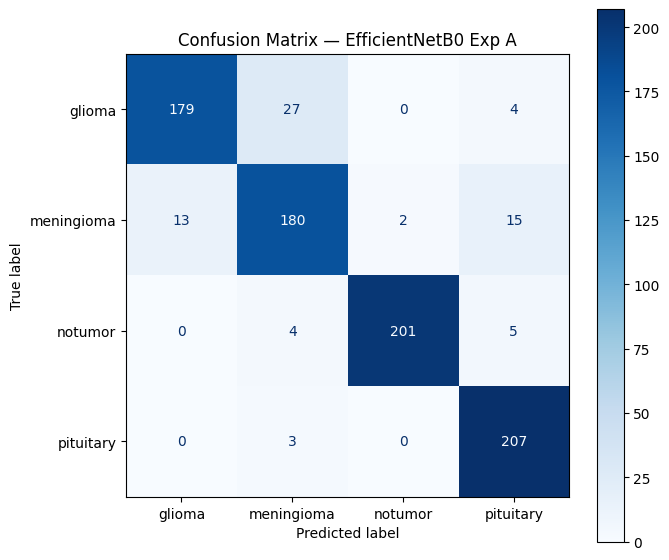

In [21]:
eff_A = tf.keras.models.load_model(str(DRIVE_DIR / 'effnet_frozen.keras'))
acc_effA, probs_effA, ytrue, ypred_effA = evaluate_model(eff_A, test_gen, 'EfficientNetB0 Exp A')

## 3. EfficientNetB0 — Experiment B: Fine-Tuning Top 30 Layers

In [ ]:
eff_B = tf.keras.models.load_model(str(DRIVE_DIR / 'effnet_frozen.keras'))

base_B = eff_B.layers[1]
base_B.trainable = True
for layer in base_B.layers[:-30]:
    layer.trainable = False

eff_B.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

trainable_ft = sum(tf.size(v).numpy() for v in eff_B.trainable_variables)
print(f'Trainable params after unfreeze: {trainable_ft:,}')

Trainable params after unfreeze: 1,825,124


Epoch 1/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 263ms/step - accuracy: 0.8352 - loss: 0.4723 - val_accuracy: 0.9143 - val_loss: 0.2598 - learning_rate: 1.0000e-05
Epoch 2/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.8607 - loss: 0.3642 - val_accuracy: 0.9036 - val_loss: 0.2955 - learning_rate: 1.0000e-05
Epoch 3/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.8842 - loss: 0.2999 - val_accuracy: 0.9012 - val_loss: 0.2913 - learning_rate: 1.0000e-05
Epoch 4/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8869 - loss: 0.2925
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
123/123 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.8878 - loss: 0.2879 - val_accuracy: 0.8988 - val_loss: 0.2824 - learning_rate: 1.0000e-05
Epoch 5/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.8964 - loss: 0.2674 - val_accuracy: 0.9000 - val_loss: 0.2810 - learning_rate: 3.0000e-06
Epoch 6/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/s

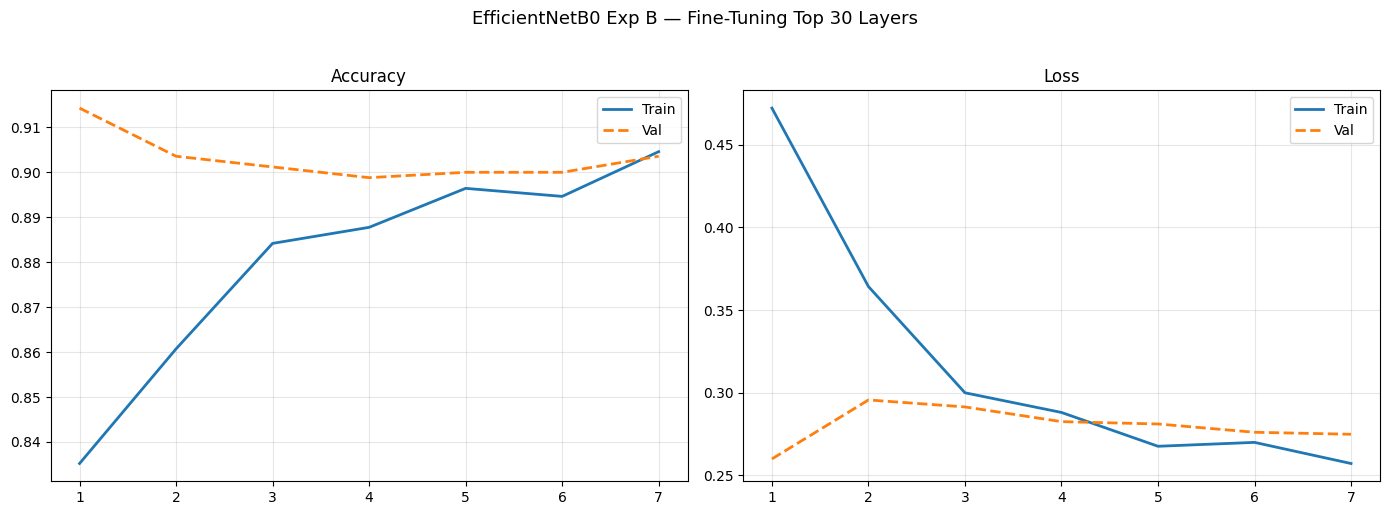

In [23]:
callbacks_effB = [
    EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(str(DRIVE_DIR / 'effnet_finetuned.keras'), save_best_only=True, monitor='val_loss'),
]

hist_effB = eff_B.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks_effB,
    verbose=1,
)
plot_history(hist_effB, 'EfficientNetB0 Exp B — Fine-Tuning Top 30 Layers')


EfficientNetB0 Exp B — Accuracy: 0.8988 | Loss: 0.2903
              precision    recall  f1-score   support

      glioma     0.8927    0.8714    0.8819       210
  meningioma     0.8526    0.7714    0.8100       210
     notumor     0.9712    0.9619    0.9665       210
   pituitary     0.8776    0.9905    0.9306       210

    accuracy                         0.8988       840
   macro avg     0.8985    0.8988    0.8973       840
weighted avg     0.8985    0.8988    0.8973       840



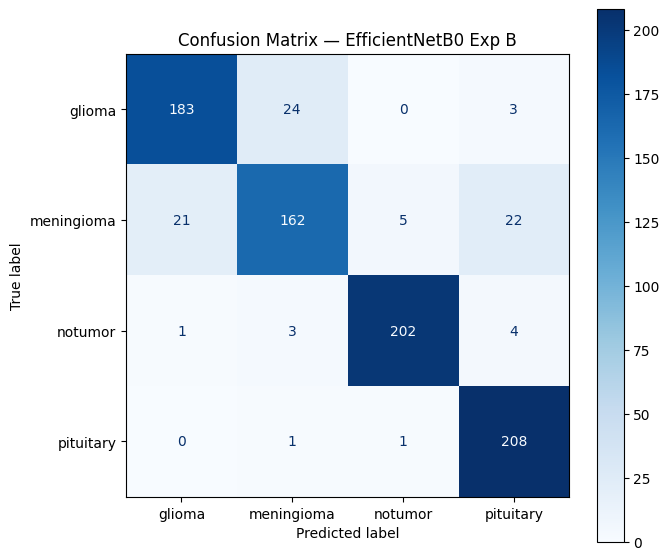

In [24]:
eff_B = tf.keras.models.load_model(str(DRIVE_DIR / 'effnet_finetuned.keras'))
acc_effB, probs_effB, ytrue, ypred_effB = evaluate_model(eff_B, test_gen, 'EfficientNetB0 Exp B')

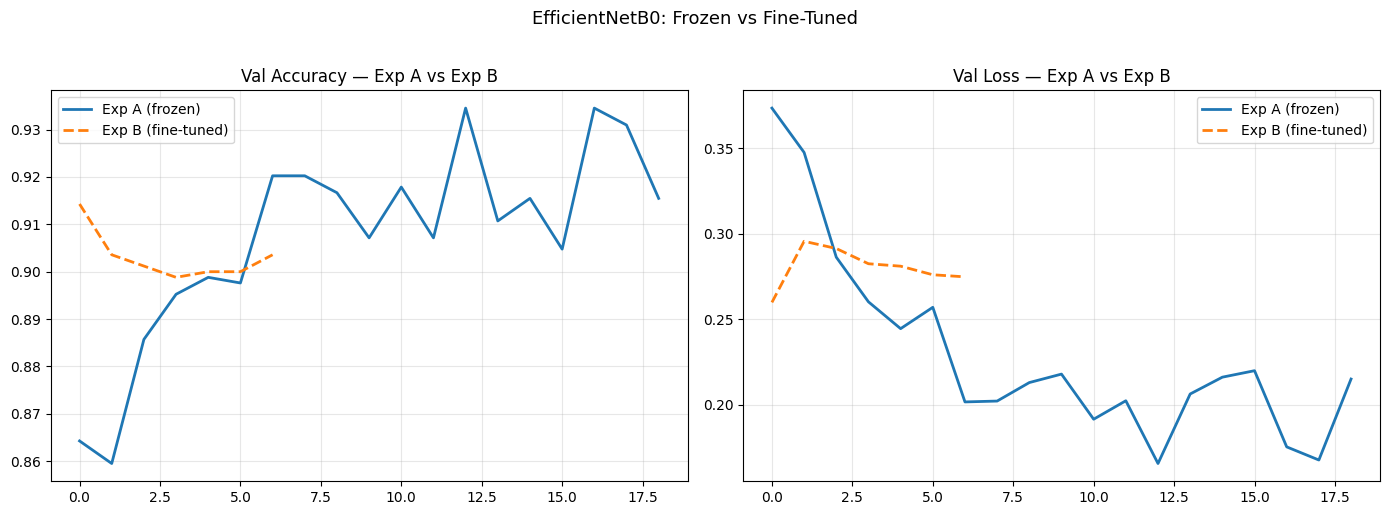

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_effA.history['val_accuracy'], label='Exp A (frozen)', lw=2)
ax1.plot(hist_effB.history['val_accuracy'], label='Exp B (fine-tuned)', lw=2, ls='--')
ax1.set_title('Val Accuracy — Exp A vs Exp B'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_effA.history['val_loss'], label='Exp A (frozen)', lw=2)
ax2.plot(hist_effB.history['val_loss'], label='Exp B (fine-tuned)', lw=2, ls='--')
ax2.set_title('Val Loss — Exp A vs Exp B'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('EfficientNetB0: Frozen vs Fine-Tuned', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. ConvNeXtSmall

## 4. ConvNeXtSmall — Experiment A: Feature Extraction (Frozen Base)

In [ ]:
from tensorflow.keras.applications import ConvNeXtSmall
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

convnext_train_datagen = ImageDataGenerator(
    preprocessing_function=convnext_preprocess,
    rotation_range=15, zoom_range=0.10,
    horizontal_flip=True, width_shift_range=0.10, height_shift_range=0.10)
convnext_val_test_datagen = ImageDataGenerator(preprocessing_function=convnext_preprocess)

convnext_train_gen = convnext_train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=16, class_mode='categorical', shuffle=True, seed=42)
convnext_val_gen = convnext_val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=16, class_mode='categorical', shuffle=False)
convnext_test_gen = convnext_val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=16, class_mode='categorical', shuffle=False)

print('ConvNeXt generators created.')

Found 3920 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
ConvNeXt generators created.


In [27]:
base_cnx_A = ConvNeXtSmall(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_cnx_A.trainable = False

inp_cnx = tf.keras.Input(shape=(224, 224, 3))
x = base_cnx_A(inp_cnx, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out_cnx = layers.Dense(4, activation='softmax')(x)

cnx_A = tf.keras.Model(inp_cnx, out_cnx, name='convnext_frozen')
cnx_A.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

trainable = sum(tf.size(v).numpy() for v in cnx_A.trainable_variables)
total     = sum(tf.size(v).numpy() for v in cnx_A.variables)
print(f'Trainable params: {trainable:,}  |  Total params: {total:,}')

Trainable params: 197,892  |  Total params: 49,652,582


Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 79s 256ms/step - accuracy: 0.7985 - loss: 0.5230 - val_accuracy: 0.8869 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.8760 - loss: 0.3311 - val_accuracy: 0.8964 - val_loss: 0.2661 - learning_rate: 0.0010
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 45s 184ms/step - accuracy: 0.8997 - loss: 0.2684 - val_accuracy: 0.9071 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 49s 198ms/step - accuracy: 0.9079 - loss: 0.2420 - val_accuracy: 0.9202 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.9230 - loss: 0.2118 - val_accuracy: 0.9024 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 46s 188ms/step - accuracy: 0.9194 - loss: 0.2106 - val_accuracy: 0.9238 - val_loss: 0.2027 - learning_rate: 0.0010
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 45s 184ms/step - accuracy: 0.9

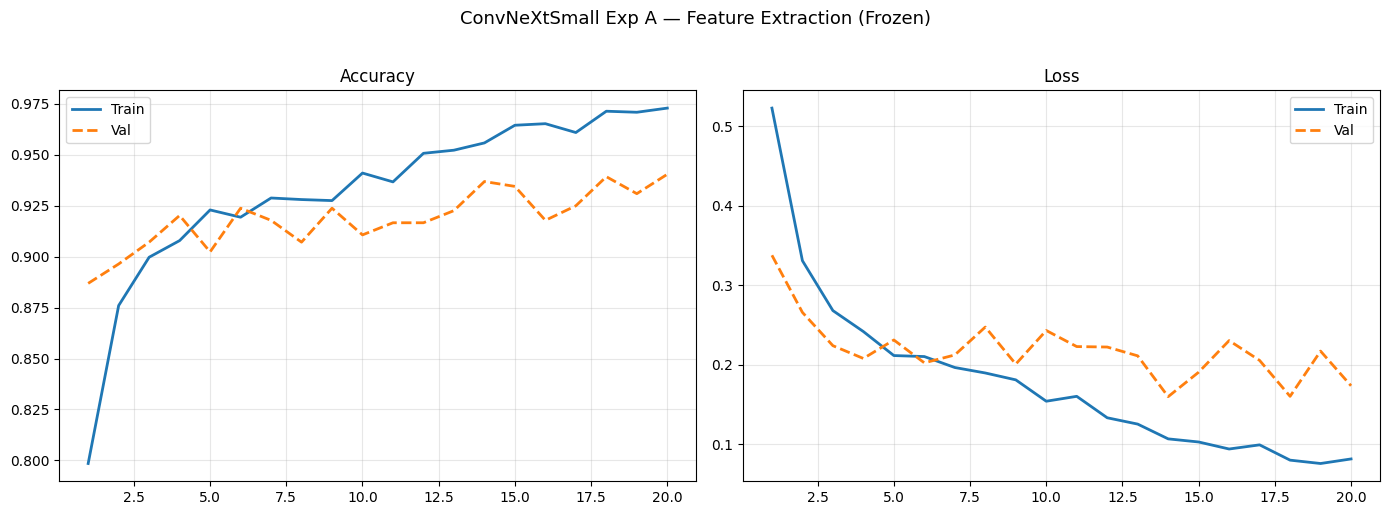

In [28]:
callbacks_cnxA = [
    EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(str(DRIVE_DIR / 'convnext_frozen.keras'), save_best_only=True, monitor='val_loss'),
]

hist_cnxA = cnx_A.fit(
    convnext_train_gen,
    validation_data=convnext_val_gen,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks_cnxA,
    verbose=1,
)
plot_history(hist_cnxA, 'ConvNeXtSmall Exp A — Feature Extraction (Frozen)')


ConvNeXtSmall Exp A — Accuracy: 0.9262 | Loss: 0.2037
              precision    recall  f1-score   support

      glioma     0.9327    0.9238    0.9282       210
  meningioma     0.8647    0.8524    0.8585       210
     notumor     0.9899    0.9333    0.9608       210
   pituitary     0.9207    0.9952    0.9565       210

    accuracy                         0.9262       840
   macro avg     0.9270    0.9262    0.9260       840
weighted avg     0.9270    0.9262    0.9260       840



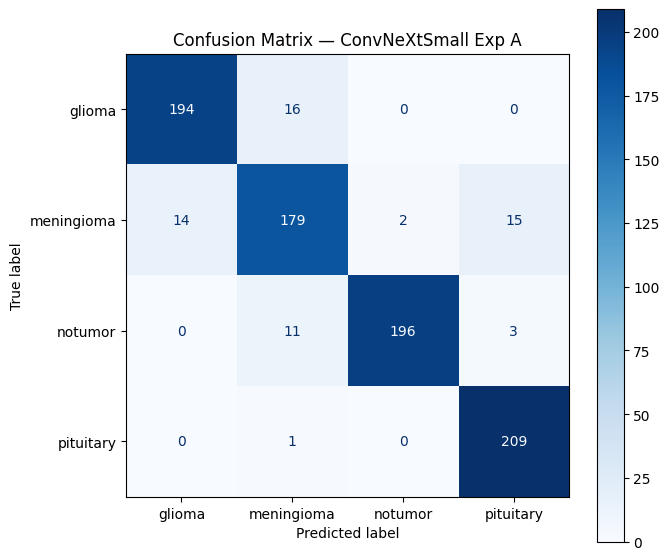

In [29]:
cnx_A = tf.keras.models.load_model(str(DRIVE_DIR / 'convnext_frozen.keras'))
acc_cnxA, probs_cnxA, ytrue, ypred_cnxA = evaluate_model(cnx_A, convnext_test_gen, 'ConvNeXtSmall Exp A')

## 5. ConvNeXtSmall — Experiment B: Fine-Tuning Top 50 Layers

In [ ]:
cnx_B = tf.keras.models.load_model(str(DRIVE_DIR / 'convnext_frozen.keras'))

base_cnx_B = cnx_B.layers[1]
base_cnx_B.trainable = True
for layer in base_cnx_B.layers[:-50]:
    layer.trainable = False

cnx_B.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

trainable_ft = sum(tf.size(v).numpy() for v in cnx_B.trainable_variables)
print(f'Trainable params after unfreeze: {trainable_ft:,}')

Trainable params after unfreeze: 19,277,316


Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 121s 369ms/step - accuracy: 0.9679 - loss: 0.0896 - val_accuracy: 0.9345 - val_loss: 0.1637 - learning_rate: 5.0000e-06
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 73s 299ms/step - accuracy: 0.9686 - loss: 0.0902 - val_accuracy: 0.9238 - val_loss: 0.1921 - learning_rate: 5.0000e-06
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 72s 292ms/step - accuracy: 0.9727 - loss: 0.0822 - val_accuracy: 0.9405 - val_loss: 0.1517 - learning_rate: 5.0000e-06
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 75s 306ms/step - accuracy: 0.9722 - loss: 0.0787 - val_accuracy: 0.9357 - val_loss: 0.1649 - learning_rate: 5.0000e-06
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 75s 305ms/step - accuracy: 0.9724 - loss: 0.0740 - val_accuracy: 0.9321 - val_loss: 0.1769 - learning_rate: 5.0000e-06
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9753 - loss: 0.0713
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
245/245 ━━━━━━━━━━━━━━━━━━━━ 74s 301ms/

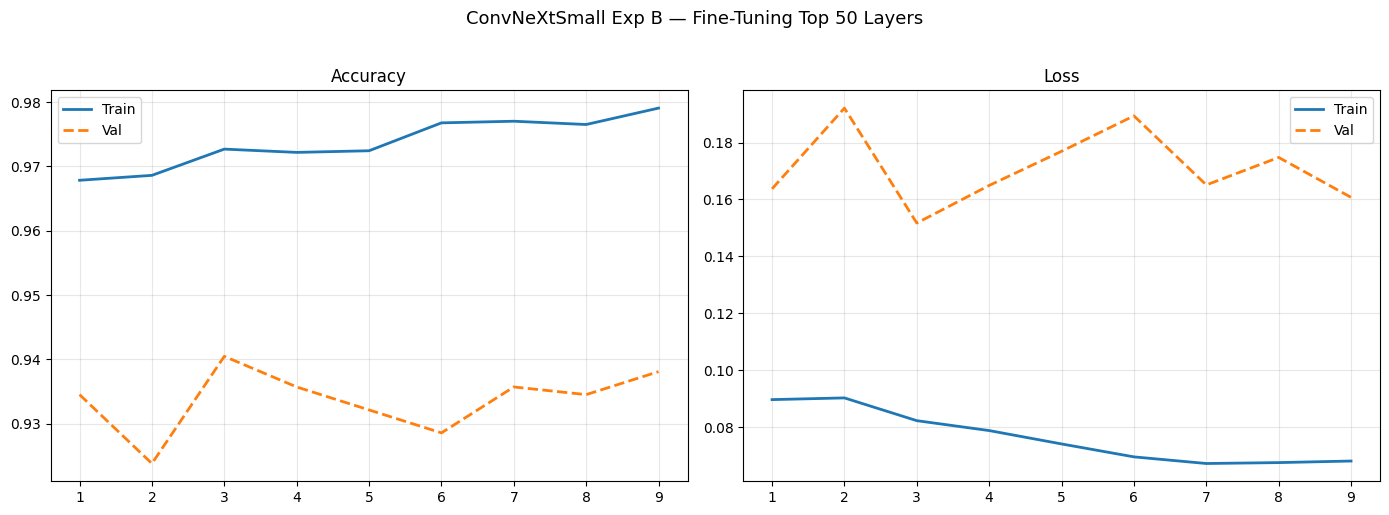

In [31]:
callbacks_cnxB = [
    EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(str(DRIVE_DIR / 'convnext_finetuned.keras'), save_best_only=True, monitor='val_loss'),
]

hist_cnxB = cnx_B.fit(
    convnext_train_gen,
    validation_data=convnext_val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_cnxB,
    verbose=1,
)
plot_history(hist_cnxB, 'ConvNeXtSmall Exp B — Fine-Tuning Top 50 Layers')


ConvNeXtSmall Exp B — Accuracy: 0.9274 | Loss: 0.1893
              precision    recall  f1-score   support

      glioma     0.8959    0.9429    0.9188       210
  meningioma     0.9278    0.7952    0.8564       210
     notumor     0.9808    0.9714    0.9761       210
   pituitary     0.9091    1.0000    0.9524       210

    accuracy                         0.9274       840
   macro avg     0.9284    0.9274    0.9259       840
weighted avg     0.9284    0.9274    0.9259       840



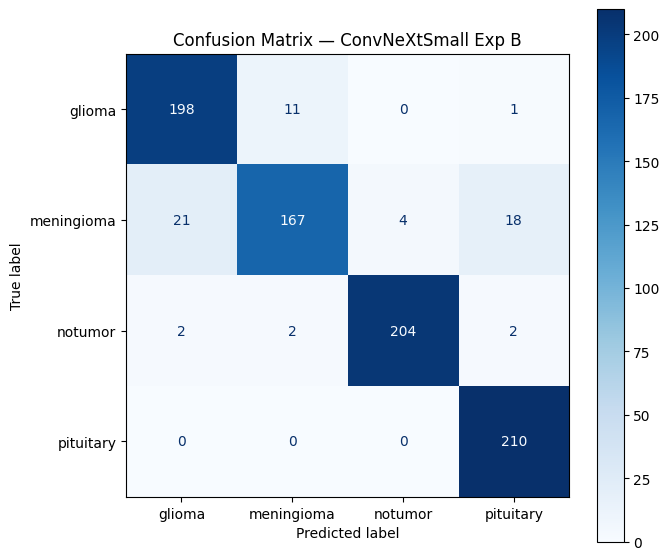

In [32]:
cnx_B = tf.keras.models.load_model(str(DRIVE_DIR / 'convnext_finetuned.keras'))
acc_cnxB, probs_cnxB, ytrue, ypred_cnxB = evaluate_model(cnx_B, convnext_test_gen, 'ConvNeXtSmall Exp B')

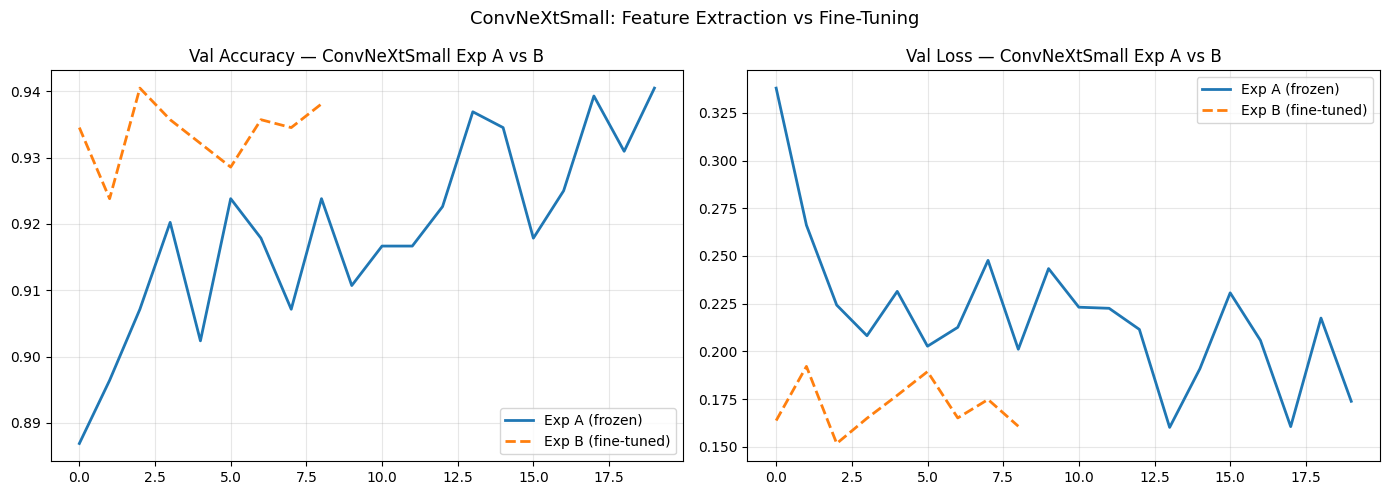

In [33]:
# Overlay ConvNeXtSmall Exp A vs Exp B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hist_cnxA.history['val_accuracy'], label='Exp A (frozen)', lw=2)
ax1.plot(hist_cnxB.history['val_accuracy'], label='Exp B (fine-tuned)', lw=2, ls='--')
ax1.set_title('Val Accuracy — ConvNeXtSmall Exp A vs B'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(hist_cnxA.history['val_loss'], label='Exp A (frozen)', lw=2)
ax2.plot(hist_cnxB.history['val_loss'], label='Exp B (fine-tuned)', lw=2, ls='--')
ax2.set_title('Val Loss — ConvNeXtSmall Exp A vs B'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('ConvNeXtSmall: Feature Extraction vs Fine-Tuning', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Hyperparameter Comparison Table


In [34]:
import cv2

def otsu_rescale(img_array):
    img = img_array / 255.0
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)
        mask = clean_mask
    return img * np.stack([mask / 255.0] * 3, axis=-1).astype(np.float32)

cnn_val_std = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
cnn_val_seg = ImageDataGenerator(preprocessing_function=otsu_rescale).flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

cnn_A = tf.keras.models.load_model(str(DRIVE_DIR / 'cnn_expA_best.keras'))
cnn_B = tf.keras.models.load_model(str(DRIVE_DIR / 'cnn_expB_best.keras'))

_, val_acc_cnn_A = cnn_A.evaluate(cnn_val_std, verbose=0)
_, val_acc_cnn_B = cnn_B.evaluate(cnn_val_seg, verbose=0)
print(f'CNN Exp A val acc: {val_acc_cnn_A:.4f}')
print(f'CNN Exp B val acc: {val_acc_cnn_B:.4f}')

Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
CNN Exp A val acc: 0.7952
CNN Exp B val acc: 0.9155


In [ ]:
hp_table = pd.DataFrame([
    {'Config': 'CNN Exp A',             'Model': 'Improved CNN',    'LR': '5e-4',  'Epochs': 30, 'Dropout': 0.3, 'Input': 'Augmented',     'Val Acc': f'{val_acc_cnn_A:.4f}'},
    {'Config': 'CNN Exp B',             'Model': 'Improved CNN',    'LR': '1e-3',  'Epochs': 30, 'Dropout': 0.3, 'Input': 'Otsu + Aug',    'Val Acc': f'{val_acc_cnn_B:.4f}'},
    {'Config': 'EfficientNetB0 Exp A',  'Model': 'EfficientNetB0',  'LR': '1e-3',  'Epochs': 25, 'Dropout': 0.3, 'Input': 'Augmented',     'Val Acc': f"{max(hist_effA.history['val_accuracy']):.4f}"},
    {'Config': 'EfficientNetB0 Exp B',  'Model': 'EfficientNetB0',  'LR': '1e-5',  'Epochs': 25, 'Dropout': 0.3, 'Input': 'Augmented (FT)','Val Acc': f"{max(hist_effB.history['val_accuracy']):.4f}"},
    {'Config': 'ConvNeXtSmall Exp A',   'Model': 'ConvNeXtSmall',   'LR': '1e-3',  'Epochs': 25, 'Dropout': 0.3, 'Input': 'Augmented',     'Val Acc': f"{max(hist_cnxA.history['val_accuracy']):.4f}"},
    {'Config': 'ConvNeXtSmall Exp B',   'Model': 'ConvNeXtSmall',   'LR': '5e-6',  'Epochs': 20, 'Dropout': 0.3, 'Input': 'Augmented (FT)','Val Acc': f"{max(hist_cnxB.history['val_accuracy']):.4f}"},
])

print('Hyperparameter Comparison:')
print(hp_table.to_string(index=False))

Hyperparameter Comparison:
              Config          Model   LR  Epochs  Dropout          Input Val Acc
           CNN Exp A   Improved CNN 5e-4      30      0.3      Augmented  0.7952
           CNN Exp B   Improved CNN 1e-3      30      0.3     Otsu + Aug  0.9155
EfficientNetB0 Exp A EfficientNetB0 1e-3      25      0.3      Augmented  0.9345
EfficientNetB0 Exp B EfficientNetB0 1e-5      25      0.3 Augmented (FT)  0.9143
 ConvNeXtSmall Exp A  ConvNeXtSmall 1e-3      25      0.3      Augmented  0.9405
 ConvNeXtSmall Exp B  ConvNeXtSmall 5e-6      20      0.3 Augmented (FT)  0.9405
